<div class="alert alert-block alert-success">
<b>Comentario general del revisor</b> <a class="tocSkip"></a><br />
Status del proyecto: <b>Aprobado</b>
</div>


¡Hola!<br />
Soy **Francisco Cortés**, estoy contento de revisar tu proyecto y ser parte de tu proceso de aprendizaje.
A lo largo del texto, haré algunas observaciones sobre mejoras en el código y también haré comentarios sobre tus percepciones sobre el tema. Si existe algún error en el código, no te preocupes, estoy aquí para ayudarte a mejorarlo, en la primera iteración te lo señalaré para que tengas la oportunidad de corregirlo, pero si aún no encuentras una solución para esta tarea, te daré una pista más precisa en la próxima iteración y también algunos ejemplos prácticos. Estaré abierto a retroalimentación y discusiones sobre el tema.<br />
Encontrarás mis comentarios a continuación - **por favor no los muevas, modifiques o borres**.
Revisaré cuidadosamente tu código para comprobar que se han cumplido con los requisitos y te proporcionaré mis comentarios en cajas verdes, amarillas o rojas como esta:

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si la ejecución fue perfecta succesfully.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si existe alguna recomendación para que tu código mejore.
</div>

<div class="alert alert-block alert-danger">

<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si existen correcciones necesarias para cumplir con los requisitos. El trabajo no puede ser aceptado si hay alguna caja roja.
</div>

Puedes responderme de la siguiente manera:

<div class="alert alert-block alert-info">
<b>Respuesta del estudiante.</b> <a class="tocSkip"></a>
</div>

# Proyecto 7 - Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [1]:
# Importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import pointbiserialr
from scipy.stats import chi2_contingency



### Cargar Dataset

In [2]:
import pandas as pd

df = pd.read_csv("/datasets/novaretail_comportamiento_clientes_2024.csv")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [3]:
df.head()


,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

💡
Después de analizar la información anterior, completa la siguiente sección.  
- Si aplica, señala la o las columnas que requieren algun cambio

Recuerda eliminar este bloque de texto antes de subir el proyecto a tu portafolio.



#### Exploración inicial de los datos

El conjunto de datos contiene 15,000 registros y 12 columnas, sin valores nulos.

Variables numéricas
Se identifican las siguientes columnas numéricas:

edad
nivel_ingreso
visitas_mes
compras_mes
gasto_publicidad_dirigida
satisfaccion
ingreso_anual

La mayoría de estas variables presentan tipos de datos adecuados para el análisis correlacional. Estas columnas permiten evaluar relaciones numéricas mediante Pearson y Spearman, especialmente respecto a la métrica principal del proyecto: ingreso_anual.

La columna id_cliente, aunque puede aparecer como numérica, no debe analizarse como una variable cuantitativa, ya que funciona como identificador único del cliente. Por esta razón, se recomienda convertirla a tipo texto.

Variables binarias
Las siguientes columnas representan variables binarias:

miembro_premium
abandono

Ambas están codificadas como 0 y 1, por lo que no requieren transformación adicional. Estas variables pueden analizarse con correlación punto-biserial frente a variables numéricas como ingreso_anual.

Variables categóricas
Se identifican las siguientes columnas categóricas:

id_cliente
tipo_dispositivo
region

tipo_dispositivo y region están correctamente definidas como variables categóricas. La columna id_cliente debe tratarse como identificador y no como variable numérica de análisis

In [4]:
# Corregir el tipo de dato
df["id_cliente"] = df["id_cliente"].astype(str)

# verificar cambios
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


In [5]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Explorar variables numéricas

In [6]:

 # Estadísticas descriptivas de variables numéricas
variables_numericas = [
    "edad",
    "nivel_ingreso",
    "visitas_mes",
    "compras_mes",
    "gasto_publicidad_dirigida",
    "satisfaccion",
    "ingreso_anual"
]

df[variables_numericas].describe()



,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,244.690000


### ✍️ Diagnóstico inicial de variables numéricas

• `edad` — Permite identificar el perfil demográfico de los clientes. Se usa como variable de contexto para revisar si la edad se relaciona con el ingreso generado.

• `nivel_ingreso` — Representa el ingreso anual estimado del cliente. Es una variable relevante porque puede estar asociada con mayor capacidad de compra.

• `visitas_mes` — Mide la actividad mensual del cliente dentro de la plataforma. Es importante para analizar si una mayor frecuencia de visitas se relaciona con mayor ingreso anual.

• `compras_mes` — Resume la cantidad de compras realizadas durante el mes. Es una variable clave de comportamiento comercial.

• `gasto_publicidad_dirigida` — Representa la inversión publicitaria asignada al usuario. Permite explorar si existe relación entre inversión publicitaria e ingreso generado.

• `satisfaccion` — Mide la percepción del cliente en una escala de 1 a 5. Puede ayudar a revisar si clientes más satisfechos generan mayor ingreso.

• `ingreso_anual` — Es la métrica principal del análisis, ya que representa el valor económico generado por cada cliente para NovaRetail+. 

#### Explorar variables binarias

In [7]:
# Verificar que cada columna tenga únicamente dos valores posibles
variables_binarias = ["miembro_premium", "abandono"]

for col in variables_binarias:
    print(col)
    print(df[col].value_counts())
    print()


miembro_premium
0    12911
1     2089
Name: miembro_premium, dtype: int64

abandono
0    12739
1     2261
Name: abandono, dtype: int64



### ✍️ **Comentario**: 
### Diagnóstico inicial de variables binarias

• miembro_premium — La variable está codificada correctamente con valores 0 y 1. La mayoría de los clientes no pertenece al programa premium, mientras que una proporción menor sí cuenta con membresía premium. Esta variable puede ser útil para analizar si pertenecer al programa premium está asociado con diferencias en el ingreso_anual.

• abandono — La variable también está codificada correctamente con valores 0 y 1. La mayoría de los clientes no abandonó la plataforma, mientras que una proporción menor sí aparece marcada como abandono. Esta variable puede ayudar a explorar si el abandono está asociado con menor ingreso anual generado.

#### Explorar variables categóricas

In [8]:
# Verificar el número de valores únicos por variable categórica
variables_categoricas = ["tipo_dispositivo", "region"]

for col in variables_categoricas:
    print(col)
    print("Valores únicos:", df[col].nunique())
    print(df[col].value_counts())
    print()

tipo_dispositivo
Valores únicos: 3
móvil         9818
escritorio    3720
tablet        1462
Name: tipo_dispositivo, dtype: int64

region
Valores únicos: 4
norte    4395
oeste    3810
sur      3726
este     3069
Name: region, dtype: int64



In [9]:
# Explorar variables categóricas y cómo se distribuyen
variables_categoricas = ["tipo_dispositivo", "region"]

for col in variables_categoricas:
    print(col)
    print("Frecuencia absoluta:")
    print(df[col].value_counts())
    print("\nFrecuencia relativa:")
    print(df[col].value_counts(normalize=True))
    print()


tipo_dispositivo
Frecuencia absoluta:
móvil         9818
escritorio    3720
tablet        1462
Name: tipo_dispositivo, dtype: int64

Frecuencia relativa:
móvil         0.654533
escritorio    0.248000
tablet        0.097467
Name: tipo_dispositivo, dtype: float64

region
Frecuencia absoluta:
norte    4395
oeste    3810
sur      3726
este     3069
Name: region, dtype: int64

Frecuencia relativa:
norte    0.2930
oeste    0.2540
sur      0.2484
este     0.2046
Name: region, dtype: float64



<div class="alert alert-block alert-success"> <b>Comentario del revisor</b> <a class="tocSkip"></a><br>

Los conjuntos datos se han revisado correctamente
</div>

### ✍️ **Comentario**:
### Diagnóstico inicial de variables categóricas

• tipo_dispositivo — La variable contiene tres categorías: móvil, escritorio y tablet. La mayoría de los clientes utiliza dispositivo móvil, seguido por escritorio y finalmente tablet. Esto sugiere que el canal móvil tiene un peso importante dentro del comportamiento de los usuarios de NovaRetail+ y puede ser relevante para analizar diferencias de ingreso o interacción por tipo de dispositivo.

• region — La variable contiene cuatro categorías: norte, oeste, sur y este. La distribución está relativamente repartida entre las regiones, aunque la región norte concentra la mayor cantidad de clientes y la región este la menor. Esta variable puede ser útil para explorar si existen diferencias geográficas asociadas con el comportamiento de compra o el ingreso anual generado.

## Supuestos

• El análisis se realiza utilizando todo el conjunto de datos disponible.
• El dataset no presenta valores nulos, por lo que no se requiere imputación de datos faltantes.
• La columna id_cliente se trata como identificador único y no como variable numérica de análisis.
• Las variables miembro_premium y abandono están codificadas como 0 y 1, por lo que pueden analizarse como variables binarias.
• Las variables tipo_dispositivo y region se analizan como variables categóricas.
• Pearson se utiliza para evaluar relaciones lineales entre variables numéricas.
• Spearman se utiliza para evaluar relaciones monotónicas o consistentes.
• Punto-biserial se utiliza para analizar relaciones entre variables binarias y numéricas.
• V de Cramér se utiliza para analizar asociaciones entre variables categóricas.

Supuesto central: este análisis identifica asociaciones entre variables, pero no permite afirmar causalidad

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

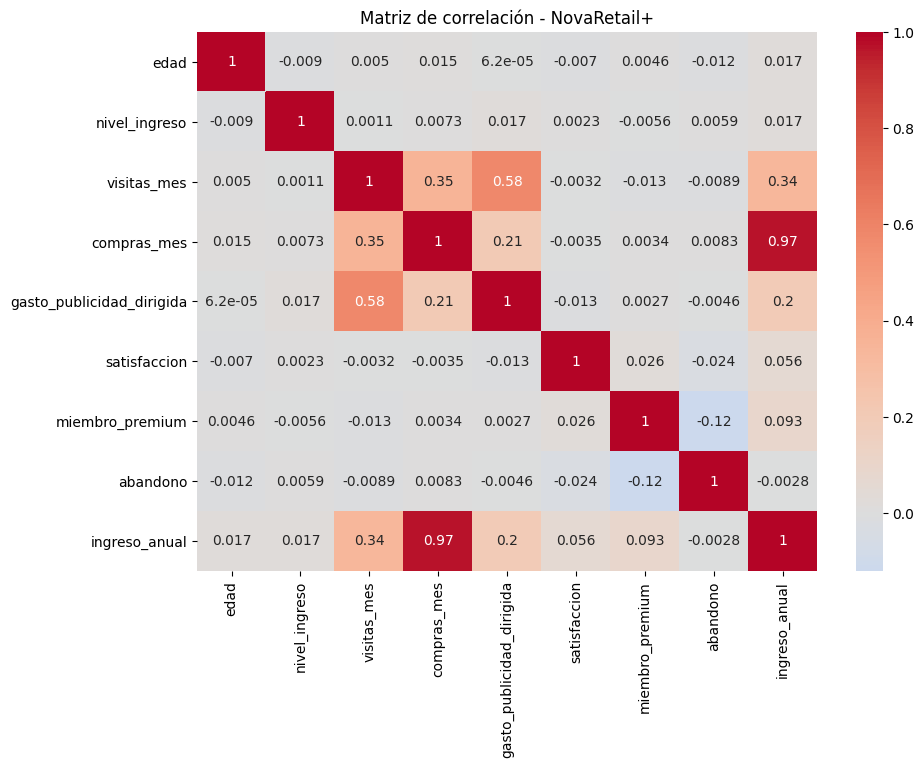

In [10]:
# Visualizar la matriz de correlación para identificar relaciones
variables_numericas = [
    "edad",
    "nivel_ingreso",
    "visitas_mes",
    "compras_mes",
    "gasto_publicidad_dirigida",
    "satisfaccion",
    "miembro_premium",
    "abandono",
    "ingreso_anual"
]

corr_matrix = df[variables_numericas].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Matriz de correlación - NovaRetail+")
plt.show()


<div class="alert alert-block alert-success"> <b>Comentario del revisor</b> <a class="tocSkip"></a><br>

Gracias al mapa de calor podemos apreciar las correlaciones entre las columnas, algunas claramente no tienen alguna correlación mientras que hay otras que claramente influyen en los resultados, bien hecho!
</div>

### ✍️ **Comentario**:


## Observaciones generales (Heatmap)

• Se observa una matriz de correlación entre las principales variables numéricas y binarias del dataset. El heatmap permite identificar de forma visual qué variables tienen relaciones positivas, negativas o débiles entre sí. Los colores más intensos representan relaciones más fuertes, mientras que los colores cercanos al centro indican relaciones débiles o cercanas a cero.

Observaciones respecto a ingreso_anual

• ingreso_anual es la métrica principal del análisis, por lo que se revisan especialmente sus correlaciones con variables de comportamiento como visitas_mes, compras_mes, gasto_publicidad_dirigida, satisfaccion, miembro_premium y abandono. Las variables con mayor correlación absoluta frente a ingreso_anual serán candidatas para un análisis más profundo mediante scatterplots y coeficientes de correlación.

## Scatterplot general

compras_mes                  0.967149
visitas_mes                  0.337147
gasto_publicidad_dirigida    0.197483
miembro_premium              0.093099
satisfaccion                 0.056171
edad                         0.017496
nivel_ingreso                0.017446
abandono                    -0.002824
Name: ingreso_anual, dtype: float64


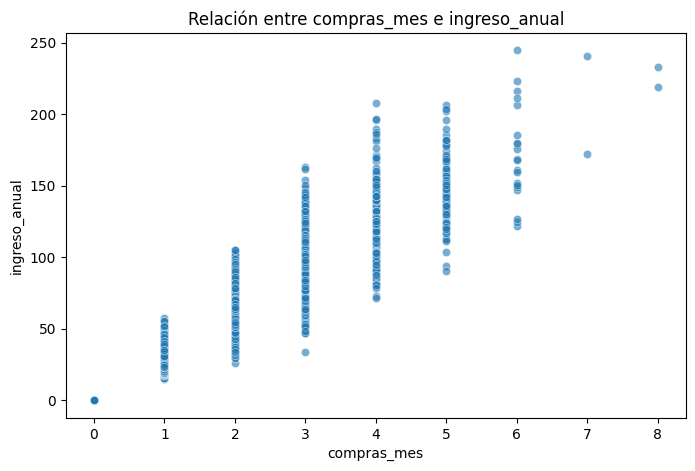

In [11]:


# Identificar la variable con mayor correlación absoluta frente a ingreso_anual
corr_ingreso = corr_matrix["ingreso_anual"].drop("ingreso_anual")

corr_ingreso_ordenada = corr_ingreso.loc[
    corr_ingreso.abs().sort_values(ascending=False).index
]

# Mostrar correlaciones ordenadas
print(corr_ingreso_ordenada)

# Seleccionar la variable más asociada con ingreso_anual
var_top = corr_ingreso_ordenada.index[0]

# Generar scatterplot general
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x=var_top,
    y="ingreso_anual",
    alpha=0.6
)

plt.title(f"Relación entre {var_top} e ingreso_anual")
plt.xlabel(var_top)
plt.ylabel("ingreso_anual")

plt.show()



<div class="alert alert-block alert-warning"> <b>Comentario del revisor</b> <a class="tocSkip"></a><br>

En este caso una gráfica "general" se refiere a graficar el resultado de todas las columans contra todas las columnas. Lo que has hecho me parece bien, pero es una gráfica especifica, por lo que debería estar en la sección de abajo
</div>

compras_mes    0.96719


Con base en los resultados del análisis de correlación, se decidió incluir un scatterplot general entre compras_mes e ingreso_anual, ya que compras_mes fue la variable con mayor correlación absoluta frente a la métrica principal del proyecto.

El gráfico evidencia una relación positiva fuerte: a medida que aumenta el número de compras mensuales, también tiende a aumentar el ingreso anual generado por el cliente. Visualmente, los puntos siguen una tendencia ascendente con una dispersión relativamente baja, lo que respalda el patrón observado previamente en la matriz de correlación.

Este hallazgo sugiere que la frecuencia de compra mensual es uno de los factores de comportamiento más asociados con el valor económico generado por los clientes de NovaRetail+. Sin embargo, el resultado debe interpretarse de manera responsable: se trata de una asociación estadística y visual, no de una relación causal. No podemos afirmar que aumentar directamente las compras mensuales cause por sí solo un mayor ingreso anual sin aplicar análisis causal, pruebas experimentales o modelos adicionales.

### Scatterplot para pares clave

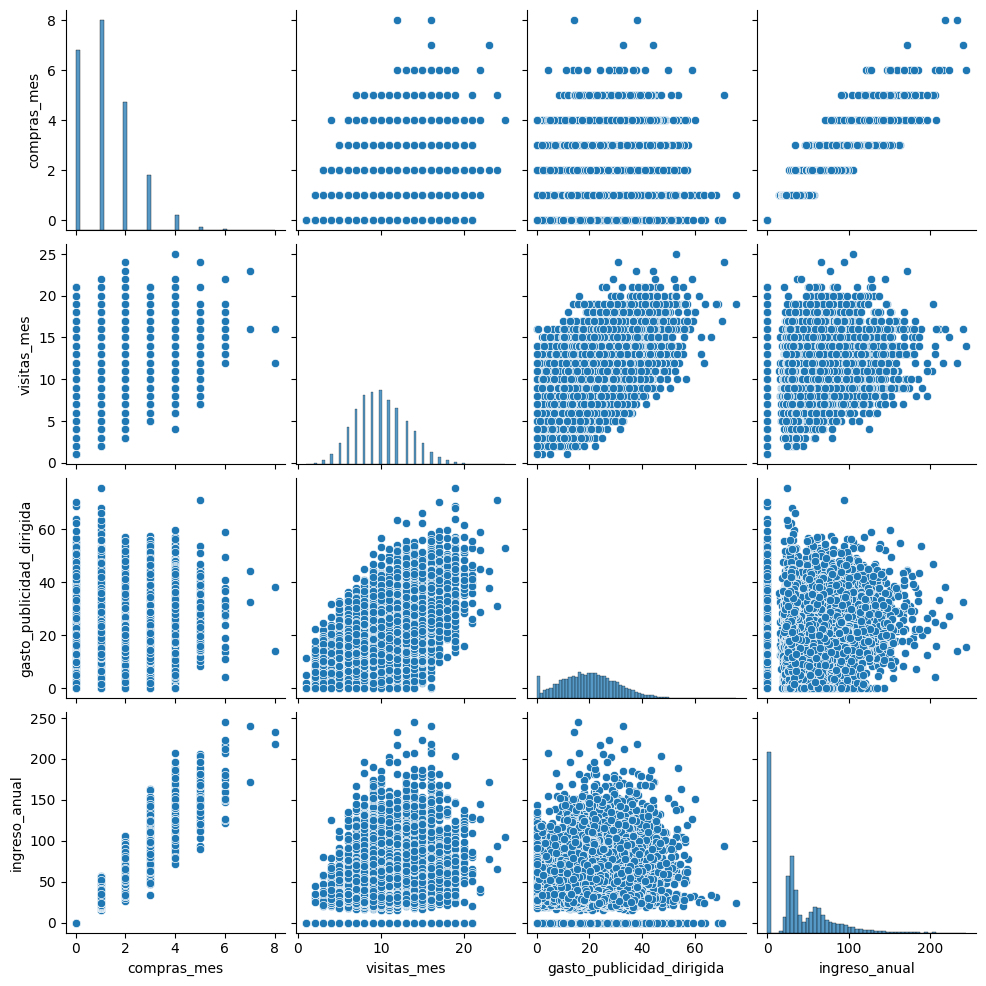

In [12]:
# Visualizar pares de variables con relaciones moderadas o fuertes
pares_clave = [
    "compras_mes",
    "visitas_mes",
    "gasto_publicidad_dirigida",
    "ingreso_anual"
]

sns.pairplot(df[pares_clave])

plt.show()


<div class="alert alert-block alert-success"> <b>Comentario del revisor</b> <a class="tocSkip"></a><br>

Gracias a estas gráficas de disperción podemos observar claramente la correlación entre las columnas antes observadas
</div>

### ✍️ **Diagnóstico**: 

### Diagnóstico inicial del scatterplot para pares clave

#### compras_mes vs ingreso_anual

La relación entre compras mensuales e ingreso anual es positiva fuerte. A medida que aumentan las compras mensuales, también tiende a aumentar el ingreso anual generado por el cliente.

La dispersión es baja a media, ya que los puntos siguen una tendencia ascendente clara. Se observan algunos clientes con ingresos anuales más altos, especialmente en niveles altos de compras mensuales.

Esta relación es muy alta y debe revisarse con el coeficiente de correlación, ya que podría indicar que compras_mes e ingreso_anual están fuertemente vinculadas.

#### visitas_mes vs ingreso_anual

La relación entre visitas mensuales e ingreso anual es positiva moderada. Los clientes con más visitas mensuales tienden a generar mayor ingreso anual, aunque la relación no es tan fuerte como con compras_mes.

La dispersión es media, porque hay variabilidad entre clientes con niveles similares de visitas. Pueden aparecer algunos clientes con alto ingreso anual sin tener el máximo número de visitas.

#### gasto_publicidad_dirigida vs ingreso_anual

La relación entre gasto publicitario dirigido e ingreso anual es positiva débil a moderada. A mayor gasto publicitario dirigido, el ingreso anual tiende a aumentar, aunque con mayor dispersión.

La dispersión es media a alta, lo que sugiere que la inversión publicitaria no explica por sí sola el ingreso anual. Pueden existir clientes con gasto publicitario alto y diferentes niveles de ingreso.

#### En todos los casos, estas relaciones se interpretan como asociaciones exploratorias y no como causalidad.



## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones observados visualmente, utilizando el método adecuado según el tipo de variables. Calcula las correlaciones de Pearson y Spearman para las variables numéricas relevantes, especialmente frente a `ingreso_anual`.



### Pearson / Spearman

In [13]:
# Calcular correlación entre variables relevantes
variables_relevantes = [
    "compras_mes",
    "visitas_mes",
    "gasto_publicidad_dirigida",
    "ingreso_anual"
]

pearson_corr = df[variables_relevantes].corr(method="pearson")
spearman_corr = df[variables_relevantes].corr(method="spearman")

print("Correlación Pearson:")
print(pearson_corr)

print("\nCorrelación Spearman:")
print(spearman_corr)

Correlación Pearson:
                           compras_mes  visitas_mes  \
compras_mes                   1.000000     0.353844   
visitas_mes                   0.353844     1.000000   
gasto_publicidad_dirigida     0.207528     0.578947   
ingreso_anual                 0.967149     0.337147   

                           gasto_publicidad_dirigida  ingreso_anual  
compras_mes                                 0.207528       0.967149  
visitas_mes                                 0.578947       0.337147  
gasto_publicidad_dirigida                   1.000000       0.197483  
ingreso_anual                               0.197483       1.000000  

Correlación Spearman:
                           compras_mes  visitas_mes  \
compras_mes                   1.000000     0.332943   
visitas_mes                   0.332943     1.000000   
gasto_publicidad_dirigida     0.192511     0.559267   
ingreso_anual                 0.967482     0.320954   

                           gasto_publicidad_dirigida  

### Observaciones de correlación Pearson / Spearman

#### compras_mes vs ingreso_anual

La correlación entre `compras_mes` e `ingreso_anual` es positiva y muy fuerte.  
En Pearson el valor es aproximadamente **0.967**, y en Spearman también se mantiene muy alto, alrededor de **0.967**.

Esto confirma numéricamente lo observado en el scatterplot: los clientes con más compras mensuales tienden a generar mayor ingreso anual.

La magnitud de esta relación es muy alta, por lo que debe interpretarse con cuidado. Puede indicar una fuerte asociación entre compras mensuales e ingreso anual, pero no permite afirmar causalidad directa.

#### visitas_mes vs ingreso_anual

La correlación entre `visitas_mes` e `ingreso_anual` es positiva moderada.  
En Pearson el valor es aproximadamente **0.337**, y en Spearman se mantiene cercano a **0.321**.

Esto sugiere que los clientes con más visitas mensuales 
tienden a generar mayor ingreso anual, aunque la relación no es tan fuerte como la observada con `compras_mes`.


#### gasto_publicidad_dirigida vs ingreso_anual

La correlación entre `gasto_publicidad_dirigida` e `ingreso_anual` es positiva débil.  
En Pearson el valor es aproximadamente **0.197**, y en Spearman es cercano a **0.185**.

Esto indica que existe cierta asociación entre la inversión publicitaria dirigida y el ingreso anual, pero la relación es débil. Por lo tanto, el gasto publicitario no parece ser el principal factor asociado al ingreso anual en este análisis.

#### Posible colinealidad

La relación más alta se observa entre `compras_mes` e `ingreso_anual`. Esta correlación es muy fuerte y debe revisarse con cautela, porque podría indicar que ambas variables están altamente vinculadas.

Sin embargo, este análisis es exploratorio. Los coeficientes muestran asociación, pero no prueban causalidad.


In [14]:
### Punto-biserial

# Calcular correlación punto-biserial entre variables binarias e ingreso_anual
variables_binarias = ["miembro_premium", "abandono"]

for col in variables_binarias:
    coef, p_value = pointbiserialr(df[col], df["ingreso_anual"])
    print(f"Punto-biserial ({col} vs ingreso_anual): {coef:.4f}")


Punto-biserial (miembro_premium vs ingreso_anual): 0.0931
Punto-biserial (abandono vs ingreso_anual): -0.0028


   
#### ✍️ **Comentario**:

### Observaciones Punto-biserial

#### miembro_premium vs ingreso_anual

La relación entre miembro_premium e ingreso_anual es positiva débil. El coeficiente punto-biserial es aproximadamente 0.0931.

Esto sugiere que los clientes premium tienden a generar un ingreso anual ligeramente mayor que los clientes no premium. Sin embargo, la magnitud de la relación es baja, por lo que la membresía premium no explica por sí sola el ingreso anual generado.

#### abandono vs ingreso_anual

La relación entre abandono e ingreso_anual es prácticamente nula. El coeficiente punto-biserial es aproximadamente -0.0028.

Esto indica que, en este dataset, la variable abandono no muestra una asociación relevante con el ingreso anual generado.

En ambos casos, los resultados deben interpretarse como asociaciones exploratorias y no como causalidad


### V de Cramér

In [15]:
# Función para calcular V de Cramér
def cramers_v(df, col_1, col_2):
    tabla = pd.crosstab(df[col_1], df[col_2])
    chi2, _, _, _ = chi2_contingency(tabla)
    n = tabla.values.sum()
    coef_v = np.sqrt(chi2 / (n * (min(tabla.shape) - 1)))
    return coef_v

In [16]:
# Aplicar V de Cramér en variables relevantes
cramer_region_dispositivo = cramers_v(df, "region", "tipo_dispositivo")

print("V de Cramér (region vs tipo_dispositivo):", cramer_region_dispositivo)


V de Cramér (region vs tipo_dispositivo): 0.012378338407739397


#### ✍️ **Comentario**: 

### Observaciones V de Cramér
#### region vs tipo_dispositivo

El análisis con V de Cramér permite evaluar la asociación entre dos variables categóricas: region y tipo_dispositivo.

El valor obtenido fue aproximadamente 0.0124, lo que indica una asociación muy débil entre la región geográfica del cliente y el tipo de dispositivo utilizado. En términos prácticos, no se observa una relación relevante entre pertenecer a una región específica y usar móvil, escritorio o tablet.

Esto sugiere que el tipo de dispositivo se distribuye de manera relativamente independiente de la región. Por lo tanto, esta relación categórica no representa un driver fuerte para explicar diferencias de comportamiento o ingreso anual dentro del dataset.

Como en el resto del análisis, este resultado debe interpretarse como una asociación exploratoria y no como causalidad.

<div class="alert alert-block alert-success"> <b>Comentario del revisor</b> <a class="tocSkip"></a><br>

Las coeficientes de correlación y asociación de la sección 4 fueron correctamente aplicados, bien hecho!
</div>

## Sección 5 - Interpretación de resultados para el negocio

✍️ **Hallazgos**: 

### 8.1 Hallazgo 1 — Compras mensuales como principal driver asociado al ingreso anual

8.1 Hallazgo 1 — Compras mensuales como principal driver asociado al ingreso anual



Evidencia visual:
El scatterplot entre compras mensuales e ingreso anual muestra una relación positiva fuerte. A medida que aumenta el número de compras mensuales, también tiende a aumentar el ingreso anual generado por el cliente.

Evidencia numérica:
La correlación entre compras_mes e ingreso_anual fue la más alta del análisis. En Pearson el valor fue aproximadamente 0.967 y en Spearman también se mantuvo alrededor de 0.967.

Interpretación:
Esto indica que la frecuencia de compra mensual es el factor de comportamiento más fuertemente asociado con el ingreso anual del cliente. Los clientes que compran más veces durante el mes tienden a representar mayor valor económico para NovaRetail+.

No podemos afirmar:
No podemos afirmar que aumentar directamente el número de compras mensuales cause por sí solo un mayor ingreso anual. El análisis identifica asociación, no causalidad.

Implicación de negocio:
NovaRetail+ debería priorizar estrategias que incentiven la recompra, la frecuencia de compra y la retención de clientes activos, ya que este comportamiento está fuertemente asociado con mayor ingreso anual.  


### Hallazgo 2 — Las visitas mensuales muestran una señal positiva de engagement

Hallazgo 2 — Las visitas mensuales muestran una señal positiva de engagement

Evidencia visual:
En los scatterplots se observa que las visitas mensuales presentan una relación positiva con el ingreso anual, aunque con mayor dispersión que compras_mes.

Evidencia numérica:
La correlación entre visitas_mes e ingreso_anual fue positiva moderada. En Pearson el valor fue aproximadamente 0.337 y en Spearman fue cercano a 0.321.

Interpretación:
Los clientes que visitan más la plataforma tienden a generar mayor ingreso anual, pero la relación no es tan fuerte como la observada con las compras mensuales. Esto sugiere que las visitas pueden ser una señal de interés o engagement, pero no necesariamente se traducen siempre en ingreso.

No podemos afirmar:
No podemos afirmar que aumentar visitas automáticamente genere más ingreso. Es posible que otros factores, como intención de compra, promociones, experiencia de usuario o perfil del cliente, influyan en la conversión.

Implicación de negocio:
El equipo de crecimiento puede usar visitas_mes como una señal temprana de interés para diseñar campañas de conversión, remarketing o personalización orientadas a convertir visitas en compras. 



<div class="alert alert-block alert-success"> <b>Comentario del revisor</b> <a class="tocSkip"></a><br>

Las observaciones que haces me parecen bien explicadas, además estan en un formato correcto
</div>

### Hallazgo 3 — El gasto publicitario y las variables categóricas no son los drivers más fuertes

Evidencia visual:
La relación entre gasto_publicidad_dirigida e ingreso_anual muestra una tendencia positiva, pero con mayor dispersión. En el análisis categórico, region y tipo_dispositivo no presentan una asociación relevante.

Evidencia numérica:
La correlación entre gasto_publicidad_dirigida e ingreso_anual fue positiva débil, aproximadamente 0.197 en Pearson y 0.185 en Spearman. Además, el V de Cramér entre region y tipo_dispositivo fue aproximadamente 0.0124, lo que indica una asociación muy débil.

Interpretación:
El gasto publicitario dirigido tiene cierta relación con el ingreso anual, pero no parece ser el principal factor asociado al valor económico del cliente. Por otro lado, la región y el tipo de dispositivo parecen comportarse de manera relativamente independiente.

No podemos afirmar:
No podemos afirmar que invertir más en publicidad dirigida cause directamente mayor ingreso anual. Tampoco podemos afirmar que una región específica determine el tipo de dispositivo utilizado por el cliente.

Implicación de negocio:
La inversión publicitaria debería evaluarse con métricas adicionales de eficiencia, como conversión, retorno de inversión o costo por compra. Además, la segmentación por región o dispositivo no debería asumirse como driver principal sin análisis complementarios


## Sección 6 - Limitaciones y próximos pasos

### **Limitaciones**

#### 9.1 Limitaciones

Este análisis es exploratorio y correlacional, por lo tanto, no permite afirmar causalidad. Aunque algunas variables muestran asociaciones fuertes con ingreso_anual, no se puede concluir que una variable cause directamente el aumento o disminución del ingreso anual.

La relación más fuerte se observa entre compras_mes e ingreso_anual, pero esta asociación debe interpretarse con cuidado, ya que ambas variables están altamente vinculadas al comportamiento de compra del cliente.

También pueden existir variables ocultas que no están incluidas en el dataset, como promociones activas, historial de descuentos, categoría de productos comprados, antigüedad del cliente o frecuencia de campañas recibidas.

Además, algunas relaciones pueden variar por segmento. Por ejemplo, el comportamiento podría cambiar según región, tipo de dispositivo, membresía premium o nivel de ingreso del cliente.

Finalmente, el análisis se basa en datos disponibles para 2024, por lo que los resultados deben actualizarse si cambian las condiciones comerciales, campañas, comportamiento de usuarios o estrategia de crecimiento de NovaRetail+.

### **Próximos pasos** 

#### 9.2 Próximos pasos

Paso 1 — Profundizar en segmentación de clientes
Analizar las relaciones principales por segmentos como región, tipo de dispositivo, nivel de ingreso y membresía premium. Esto permitiría identificar si los patrones observados se mantienen igual en todos los grupos o si existen diferencias relevantes.

Paso 2 — Analizar conversión entre visitas y compras
Dado que visitas_mes tiene una relación positiva moderada con ingreso_anual, se recomienda estudiar cuántas visitas se convierten realmente en compras. Esto ayudaría a entender mejor el paso entre interés, navegación y generación de ingreso.

Paso 3 — Evaluar eficiencia del gasto publicitario
La variable gasto_publicidad_dirigida presenta una relación positiva débil con ingreso_anual, por lo que se recomienda complementar el análisis con métricas como retorno de inversión, costo por compra, tasa de conversión y revenue generado por campaña.

Paso 4 — Construir modelos predictivos o pruebas controladas
Como siguiente etapa, NovaRetail+ podría desarrollar modelos predictivos para estimar ingreso anual esperado por cliente o diseñar experimentos A/B para validar si ciertas acciones comerciales generan cambios reales en compras, visitas o retención.

Paso 5 — Actualizar el análisis periódicamente
Este análisis debería repetirse con nuevos datos para verificar si los patrones se mantienen en el tiempo, especialmente después de campañas, cambios de producto, promociones o nuevas estrategias de retención.

# Comentario general del revisor
<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Has realizado un buen trabajo, me doy cuenta de que has aplicado los conocimientos que has adquirido durante el curso, los procedimientos realizados son correctos, este es un ejercicio que nos ayuda a entender y comprobar que la correlación no siempre indica causalidad.<br/>    
<br/>    
Continúa con el buen trabajo y mucho éxito en el siguiente Sprint!
</div>


<div class="alert alert-block alert-success">
<b>Aspectos positivos del proyecto</b> <a class="tocSkip"></a><br />

- Las observaciones intermedias, así como las conclusiones finales me parecen buenas
- El proyecto esta ordenado
- El proyecto es directo y conciso
    
</div> 
